In [1]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [4]:
# Install gdown and download dataset directly
!pip install gdown -q

import gdown
import zipfile
import os

# Download the dataset from Google Drive
file_id = "1MNdDKYB0x0PEW7P71bE1Jx_uLllvORA0"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "dataset.zip", quiet=False)

# Unzip it
with zipfile.ZipFile("dataset.zip", 'r') as z:
    z.extractall("/content/dataset_raw")

print("Downloaded and extracted!")
print(os.listdir("/content/dataset_raw"))

Downloading...
From (original): https://drive.google.com/uc?id=1MNdDKYB0x0PEW7P71bE1Jx_uLllvORA0
From (redirected): https://drive.google.com/uc?id=1MNdDKYB0x0PEW7P71bE1Jx_uLllvORA0&confirm=t&uuid=aa7be643-2b03-489a-906c-381cffca8c61
To: /content/dataset.zip
100%|██████████| 83.6M/83.6M [00:02<00:00, 32.2MB/s]


Downloaded and extracted!
['Project5_Ag_Crop and weed detection']


In [5]:
import os

base = "/content/dataset_raw/Project5_Ag_Crop and weed detection"

for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # only show file counts, not all files
        print(f"{'  ' * (level+1)}{len(files)} files")


Project5_Ag_Crop and weed detection/
  3 files


In [6]:
base = "/content/dataset_raw/Project5_Ag_Crop and weed detection"

for item in os.listdir(base):
    full = os.path.join(base, item)
    size = os.path.getsize(full)
    print(f"{item}  →  {size/1024/1024:.1f} MB")

~$oject1.docx  →  0.0 MB
Project5_Ag_Crop and weed detection.zip  →  79.2 MB
Project5_Ag_Crop and weed detection.docx  →  0.8 MB


In [7]:
import zipfile

inner_zip = "/content/dataset_raw/Project5_Ag_Crop and weed detection/Project5_Ag_Crop and weed detection.zip"

with zipfile.ZipFile(inner_zip, 'r') as z:
    z.extractall("/content/data")

print("Extracted!")
print(os.listdir("/content/data"))

Extracted!
['agri_data', 'classes.txt']


In [8]:
# Check classes and folder structure
print("Classes:")
print(open("/content/data/classes.txt").read())

print("\nInside agri_data:")
for item in os.listdir("/content/data/agri_data"):
    path = f"/content/data/agri_data/{item}"
    count = len(os.listdir(path)) if os.path.isdir(path) else "-"
    print(f"  {item}/  →  {count} files")

Classes:
crop
weed

Inside agri_data:
  data/  →  2600 files


In [9]:
import os, shutil, random

src = "/content/data/agri_data/data"

# Separate image files from label files
all_files = os.listdir(src)
images = [f for f in all_files if f.endswith(('.jpg', '.png', '.jpeg'))]
print(f"Total images: {len(images)}")

# Create train/val folder structure
for split in ['train', 'val']:
    for sub in ['images', 'labels']:
        os.makedirs(f"/content/dataset/{split}/{sub}", exist_ok=True)

# 80/20 split
random.seed(42)
random.shuffle(images)
split_idx = int(0.8 * len(images))
train_imgs = images[:split_idx]
val_imgs   = images[split_idx:]

# Copy images + their label files
def copy_split(img_list, split):
    for img in img_list:
        name = os.path.splitext(img)[0]
        lbl  = name + ".txt"
        shutil.copy(f"{src}/{img}", f"/content/dataset/{split}/images/{img}")
        if os.path.exists(f"{src}/{lbl}"):
            shutil.copy(f"{src}/{lbl}", f"/content/dataset/{split}/labels/{lbl}")

copy_split(train_imgs, 'train')
copy_split(val_imgs,   'val')

print(f"Train images: {len(os.listdir('/content/dataset/train/images'))}")
print(f"Val images:   {len(os.listdir('/content/dataset/val/images'))}")
print("Split done!")

Total images: 1300
Train images: 1040
Val images:   260
Split done!


In [10]:
# Create data.yaml
yaml = """
path: /content/dataset
train: train/images
val: val/images

nc: 2
names: ['crop', 'weed']
"""
with open('/content/data.yaml', 'w') as f:
    f.write(yaml)
print("data.yaml created!")

# Start training
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(data='/content/data.yaml', epochs=50, imgsz=512, device=0)

data.yaml created!
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7edc56665670>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


0: 512x512 1 crop, 41.3ms
1: 512x512 2 weeds, 41.3ms
2: 512x512 1 crop, 41.3ms
3: 512x512 1 weed, 41.3ms
4: 512x512 3 crops, 41.3ms
Speed: 6.7ms preprocess, 41.3ms inference, 4.0ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/results


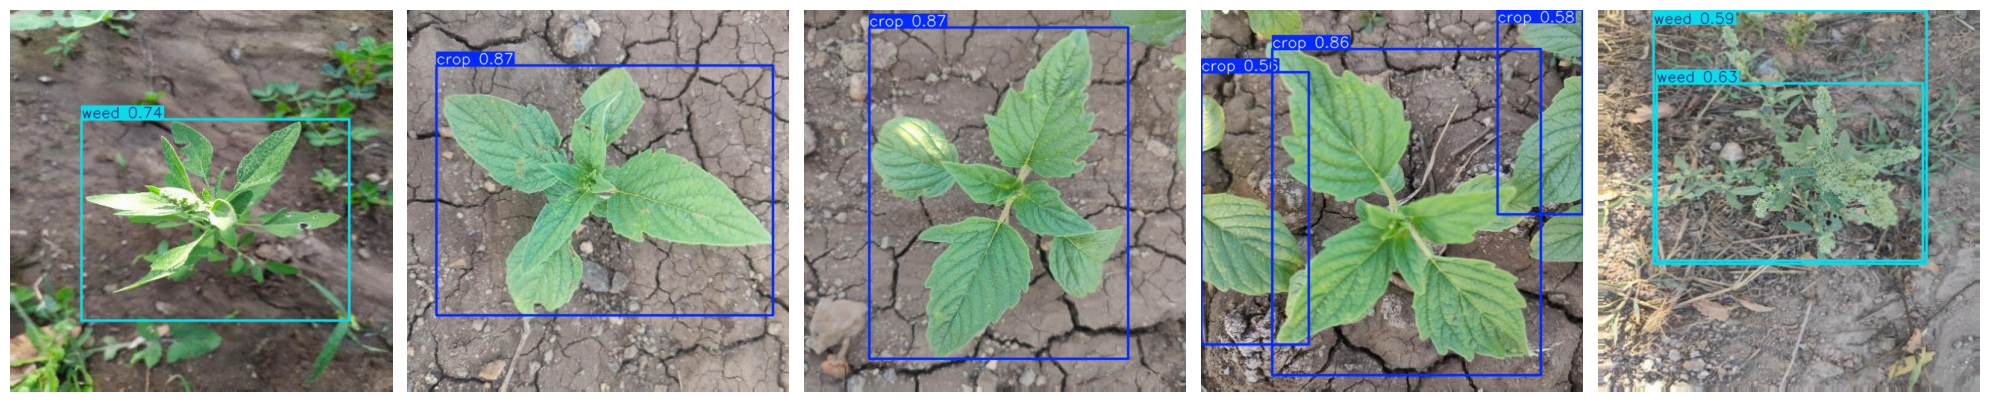

Done!


In [11]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from glob import glob

# Load best trained model
model = YOLO('runs/detect/train/weights/best.pt')

# Run on 5 validation images
val_images = glob('/content/dataset/val/images/*')[:5]
model.predict(val_images, save=True, conf=0.4, project='/content', name='results')

# Display them
result_imgs = glob('/content/results/*.jpg') + glob('/content/results/*.png')
fig, axes = plt.subplots(1, min(5, len(result_imgs)), figsize=(20, 5))
for ax, img_path in zip(axes, result_imgs):
    ax.imshow(mpimg.imread(img_path))
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/detection_results.png', dpi=150)
plt.show()
print("Done!")

In [12]:
from google.colab import files
files.download('/content/detection_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Download the trained model weights
from google.colab import files
files.download('runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>